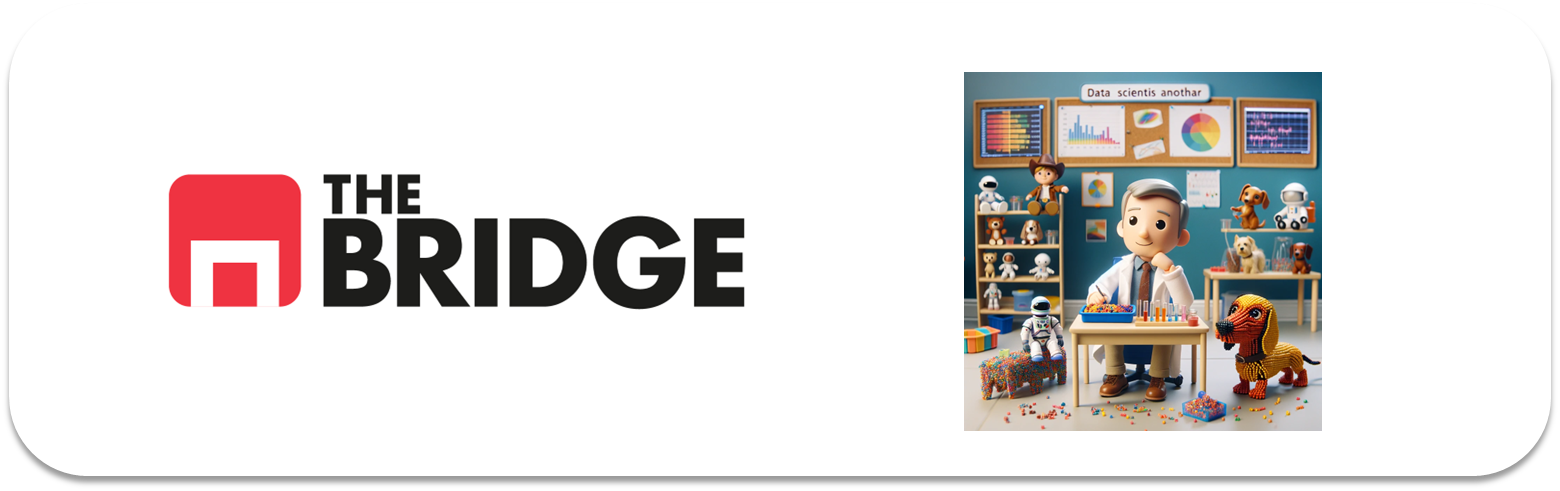

## PRACTICA OBLIGATORIA: **Análisis Univariante**

* La práctica obligatoria de esta unidad consiste en hacer el análisis univariante completo de un dataset con el que acabarás muy familiarizado, el manifiesto de pasajeros del Titanic. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook. Te dejo una que vas a necesitar sí o sí

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import bootcampviztools

### #1 Preparación


### #1.1


Carga en un dataframe los datos del titanic a partir de un dataset de seaborn. Para ello:

* ejecuta ```python sns.get_dataset_names()```
* localiza el nombre que puede ser el adecuado para el ejercicio
* Asigna la salida de ```sns.load_dataset(<nombre_del_dataset>)``` a una variable "df_titanic"

In [2]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [3]:
df_titanic = sns.load_dataset("titanic")

### #1.2

Muestra una porción del dataset ("df_titanic") y su info general. ¿Hay nulos?

In [4]:
df_titanic.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


In [5]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


### Nulos
Hay nulos en las columnas `age`, `embarked`, `deck` y `embark_town`

### #1.3

Obtén el porcentaje de nulos y decide que hacer con las columnas con nulos y ejecútalo. Además deshazte de la columna "parch" que no la emplearemos.

In [6]:
df_titanic.drop(columns="parch", inplace=True)
df_titanic

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [7]:
for i in df_titanic.keys():
    if df_titanic[i].isna().any():
        print(i)
        print(df_titanic[i].isna().value_counts(dropna=False, normalize=True))
        print("\n")

age
age
False    0.801347
True     0.198653
Name: proportion, dtype: float64


embarked
embarked
False    0.997755
True     0.002245
Name: proportion, dtype: float64


deck
deck
True     0.772166
False    0.227834
Name: proportion, dtype: float64


embark_town
embark_town
False    0.997755
True     0.002245
Name: proportion, dtype: float64




In [8]:
# Hago una primera pasada con para obtener los valores de su columna equivalente 'embarked' ~ 'embark_town'
def embark_town_nan(df):
    mascara = df["embark_town"].isna() & df["embarked"].notna()
    df.loc[mascara, "embark_town"] = df.loc[mascara, "embarked"]
    return df["embark_town"].value_counts(dropna=False)

def embarked_nan(df):
    mascara = df["embarked"].isna() & df["embark_town"].notna()
    df.loc[mascara, "embarked"] = df.loc[mascara, "embark_town"]
    return df["embarked"].value_counts(dropna=False)
    
embark_town_nan(df_titanic)
embarked_nan(df_titanic)

embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

In [9]:
# Como quedan 2 NaN en cada columna elimino esas 2 filas
df_titanic = df_titanic.dropna(subset=['embarked', 'embark_town'])

In [10]:
# Calculo la media de fare por clase excluyendo 0.0 y NaN
media_por_clase = df_titanic[df_titanic["fare"] > 0].groupby("class")["fare"].mean()

# Reemplazo 0.0 por NaN para tratarlos igual
df_titanic["fare"] = df_titanic["fare"].replace(0.0, float("nan"))

# Relleno los NaN de 'fare' con la media de antes
media_por_fila = df_titanic["class"].map(media_por_clase)
df_titanic["fare"] = df_titanic["fare"].fillna(media_por_fila)
df_titanic["fare"].isna().value_counts(dropna=False)

fare
False    889
Name: count, dtype: int64

In [11]:
# Relleno los NaN de 'deck' con el valor más común según la clase
def deck_nan(df):
    if df.mode().empty:
        return df
    return df.fillna(df.mode()[0])

df_titanic["deck"] = df_titanic.groupby("class")["deck"].transform(deck_nan)


df_titanic["deck"].value_counts(dropna=False)

deck
F    660
C    100
B     45
D     33
E     32
A     15
G      4
Name: count, dtype: int64

In [12]:
# Relleno los null de 'age' con las medias de cada clase según sexo
def fill_age(df):
    return df.fillna(df.median().astype(int))

df_titanic["age"] = df_titanic.groupby(["pclass", "sex"])["age"].transform(fill_age).astype(int)
df_titanic["age"]

0      22
1      38
2      26
3      35
4      35
       ..
886    27
887    19
888    21
889    26
890    32
Name: age, Length: 889, dtype: int64

In [13]:
df_titanic.isna().value_counts(dropna=False)

survived  pclass  sex    age    sibsp  fare   embarked  class  who    adult_male  deck   embark_town  alive  alone
False     False   False  False  False  False  False     False  False  False       False  False        False  False    889
Name: count, dtype: int64

### #1.4
Sobre el dataset "limpio". Rellena la tabla de descripción (muy breve) de lo que es cada columna en función de su nombre y los valores. Para ayudarte:
* Se trata del dataset que reune lo más parecido a un manifiesto de supervivientes y fallecidos en el viaje.
* sibsp: Es el numero de familiares que viajan con la persona indicada en el manifiesto (lista de pasajeros)
* embarked: Es la incial de la letra de la ciudad donde embarcó la persona.


In [14]:
df_titanic.who.value_counts()

who
man      537
woman    269
child     83
Name: count, dtype: int64



| Columna/Variable | Descripción |
| ---------------- | ----------- |
|Survided|Indica si el pasajero ha sobrevivido o no|
|pclass|Valor numérico de la clase en la que viajaba|
|sex|indica el género del pasajero|
|age|indica a edad del pasajero|
|sibsp|Indica el número de pasajeros que viajaban con él|
|fare|Precio del billete que pagó|
|embarked|Inicial de la ciudad donde embarcó|
|class|Indica la clase a la que pertenece el pasaje (First, Second o Third)|
|who|Indica si se trata de un hombre, una mujer o un niñ@|
|adult_male|Indica si se trata de un hombre adulto|
|deck|Indica el puente en el que viajaba|
|embark_town|Indica la ciudad en la que embarcó|
|alive|Indica si sobrevivió al hundimiento|
|alone|Indica si viajaba solo o acompañado|



### #1.5

Busca en internet las tres ciudades que visitó el Titanic antes de poner rumbo a su destino y llegar a alta mar. Cambia las iniciales por esos valores.

In [15]:
df_titanic.loc[df_titanic["embarked"] == "S", "embarked"] = "Southampton"
df_titanic.loc[df_titanic["embarked"] == "C", "embarked"] = "Cherbourg"
df_titanic.loc[df_titanic["embarked"] == "Q", "embarked"] = "Queenstown"

df_titanic.head(10)

,survived,pclass,sex,age,sibsp,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22,1,7.2500,Southampton,Third,man,True,F,Southampton,no,False
1,1,1,female,38,1,71.2833,Cherbourg,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26,0,7.9250,Southampton,Third,woman,False,F,Southampton,yes,True
3,1,1,female,35,1,53.1000,Southampton,First,woman,False,C,Southampton,yes,False
4,0,3,male,35,0,8.0500,Southampton,Third,man,True,F,Southampton,no,True
5,0,3,male,25,0,8.4583,Queenstown,Third,man,True,F,Queenstown,no,True
6,0,1,male,54,0,51.8625,Southampton,First,man,True,E,Southampton,no,True
7,0,3,male,2,3,21.0750,Southampton,Third,child,False,F,Southampton,no,False
8,1,3,female,27,0,11.1333,Southampton,Third,woman,False,F,Southampton,yes,False
9,1,2,female,14,1,30.0708,Cherbourg,Second,child,False,F,Cherbourg,yes,False


### #2 Análisis

Sabiendo que el objetivo de nuestro análisis es hacer un estudio de la superviviencia y mortalidad en el viaje... Haz un análisis univariante completo y ordenado de las siguientes variables:
["survived","who","age","fare","class","embarked","alone"]
Nota: Si quieres añadir más, perfecto.

Separa el análisis en categóricas (incluyendo binarias) y numéricas. Muestra valores, gráficas y conclusiones/observaciones (2 o 3 por variable)

In [16]:
df_limpio = df_titanic[["survived","who","age","fare","class","embarked","alone"]].copy()
df_limpio

,survived,who,age,fare,class,embarked,alone
0,0,man,22,7.2500,Third,Southampton,False
1,1,woman,38,71.2833,First,Cherbourg,False
2,1,woman,26,7.9250,Third,Southampton,True
3,1,woman,35,53.1000,First,Southampton,False
4,0,man,35,8.0500,Third,Southampton,True
...,...,...,...,...,...,...,...
886,0,man,27,13.0000,Second,Southampton,True
887,1,woman,19,30.0000,First,Southampton,True
888,0,woman,21,23.4500,Third,Southampton,False
889,1,man,26,30.0000,First,Cherbourg,True


In [17]:
df_limpio.info()

<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  889 non-null    int64   
 1   who       889 non-null    str     
 2   age       889 non-null    int64   
 3   fare      889 non-null    float64 
 4   class     889 non-null    category
 5   embarked  889 non-null    str     
 6   alone     889 non-null    bool    
dtypes: bool(1), category(1), float64(1), int64(2), str(2)
memory usage: 43.5 KB


In [18]:
df_tipificacion = pd.DataFrame([df_limpio.nunique(), df_limpio.nunique()/len(df_limpio) * 100, df_limpio.dtypes]).T.rename(columns = {0: "Card",1: "%_Card", 2: "Tipo"})
df_tipificacion

,Card,%_Card,Tipo
survived,2,0.224972,int64
who,3,0.337458,str
age,71,7.986502,int64
fare,249,28.008999,float64
class,3,0.337458,category
embarked,3,0.337458,str
alone,2,0.224972,bool


In [19]:
df_tipificacion["Clasificada_como"] = "Categorica" # Partiendo de que casi todas parecen categóricas
df_tipificacion.loc[df_tipificacion.Card == 2, "Clasificada_como"] = "Binaria"
df_tipificacion.loc[df_tipificacion["Card"] > 10, "Clasificada_como"] ="Numerica Discreta"
df_tipificacion.loc[df_tipificacion["%_Card"] > 30, "Clasificada_como"] = "Numerica Continua"
df_tipificacion

,Card,%_Card,Tipo,Clasificada_como
survived,2,0.224972,int64,Binaria
who,3,0.337458,str,Categorica
age,71,7.986502,int64,Numerica Discreta
fare,249,28.008999,float64,Numerica Discreta
class,3,0.337458,category,Categorica
embarked,3,0.337458,str,Categorica
alone,2,0.224972,bool,Binaria


| Columna/Variable | Descripción |Tipo de variable|Importancia inicial|Notas|
| ---------------- | ----------- | ----------- | ----------- | ----------- |
|Survived|Indicador de supervivencia|Binaria|0|Indica si el pasajero ha sobrevivido o no|
|who|Indica si se trata de un hombre, una mujer o un niñ@|Categórica|1|Demográfica|
|age|Edad del pasajero|Numérica discreta|2|Demográfica. Poco interesante de primeras|
|fare|Precio del billete|Numérica discreta|1|Impacta en posibilidades de supervivencia|
|class|Clase a la que pertenece el pasaje (First, Second o Third)|Categórica|0|Clave para evaluar la supervivencia de clases inferiores|
|embarked|Inicial de la ciudad donde embarcó|Categórica|2|En principio no es relevante|
|alone|Indica si viajaba solo o acompañado|Binaria|2|Poco relevante por si sola, podría ser interesante verla agrupada con 'who'|

### #2.1 Categóricas

In [20]:
categoricas = [
    "survived",
    "who",
    "class",
    "embarked",
    "alone"
]

#### Tendencia central categóricas

In [21]:
df_limpio[categoricas].mode().T

,0
survived,0
who,man
class,Third
embarked,Southampton
alone,True


Perfil de pasajero: hombre que embarcó solo en Southampton en 3ª clase y falleció

#### Frecuencias absolutas

In [22]:
#Frecuencias absolutas
for catego in categoricas:
    print(f"Para {catego}")
    print(df_limpio[catego].value_counts())
    print("\n")

Para survived
survived
0    549
1    340
Name: count, dtype: int64


Para who
who
man      537
woman    269
child     83
Name: count, dtype: int64


Para class
class
Third     491
First     214
Second    184
Name: count, dtype: int64


Para embarked
embarked
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64


Para alone
alone
True     535
False    354
Name: count, dtype: int64




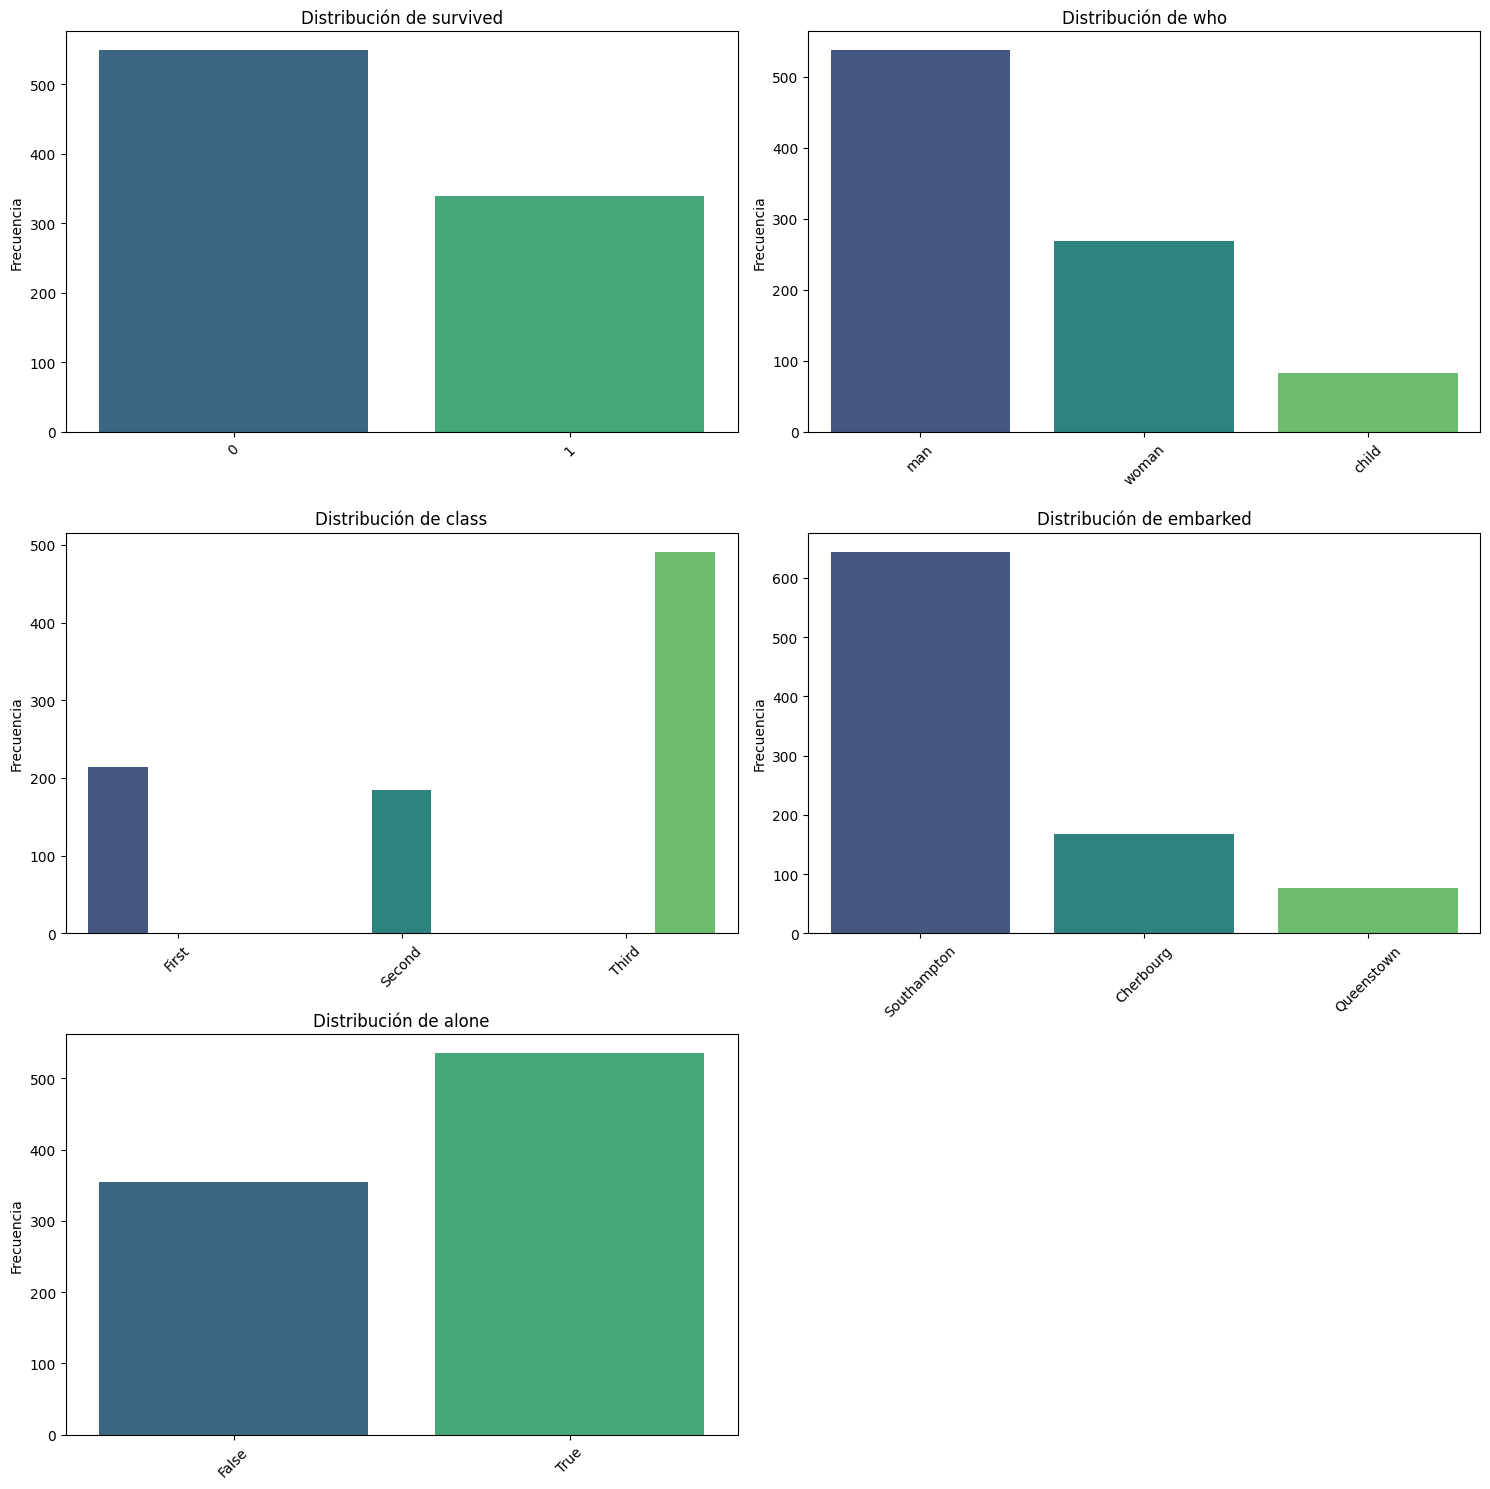

In [23]:
bootcampviztools.pinta_distribucion_categoricas(df_limpio, categoricas)

#### Frecuencias relativas

In [24]:
# Frecuencias relativas
for catego in categoricas:
    print(f"Para {catego}")
    print(df_limpio[catego].value_counts()/len(df_limpio)*100)
    print("\n")

Para survived
survived
0    61.754781
1    38.245219
Name: count, dtype: float64


Para who
who
man      60.404949
woman    30.258718
child     9.336333
Name: count, dtype: float64


Para class
class
Third     55.230596
First     24.071991
Second    20.697413
Name: count, dtype: float64


Para embarked
embarked
Southampton    72.440945
Cherbourg      18.897638
Queenstown      8.661417
Name: count, dtype: float64


Para alone
alone
True     60.179978
False    39.820022
Name: count, dtype: float64




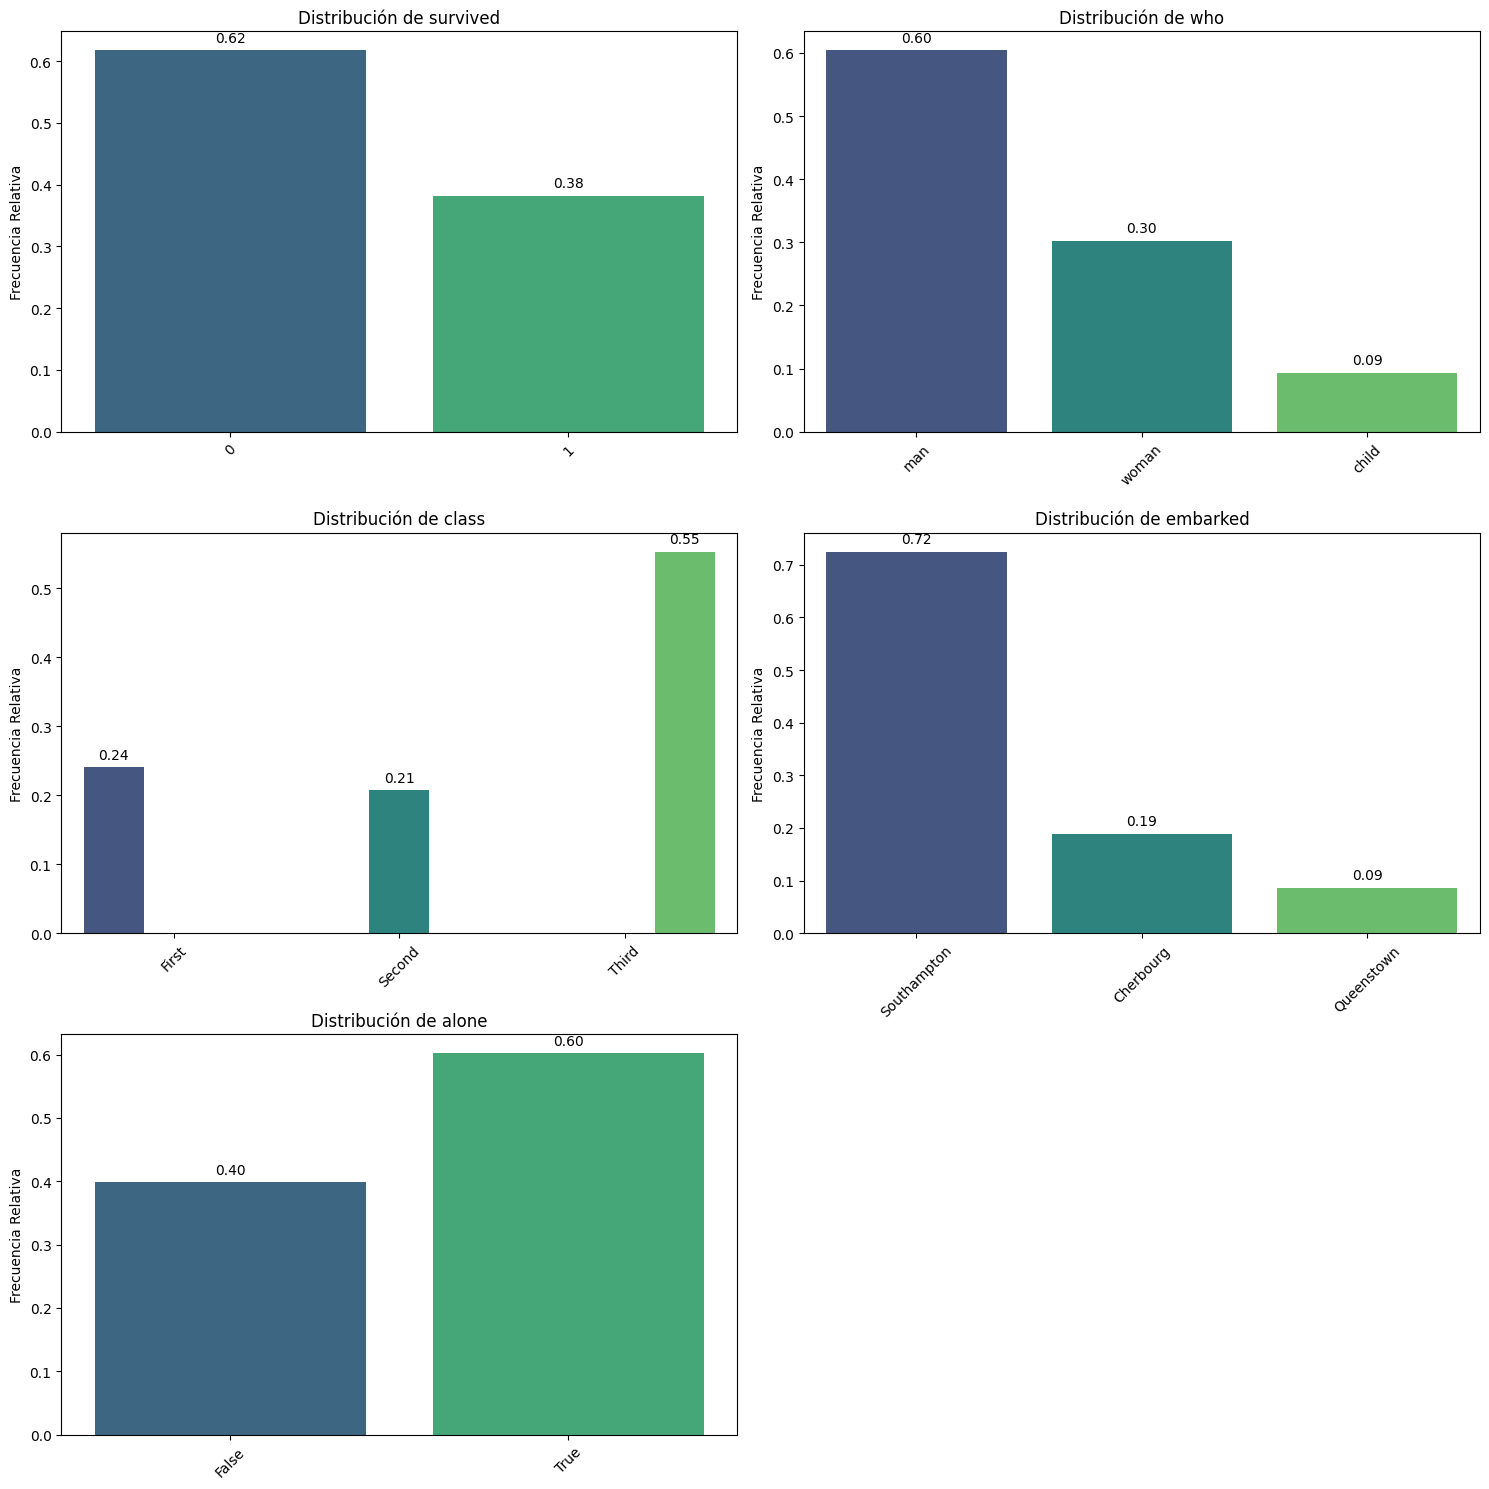

In [25]:
bootcampviztools.pinta_distribucion_categoricas(df_limpio, categoricas, relativa=True, mostrar_valores=True)

### #2.2 Numéricas

In [26]:
numericas = [
    "age",
    "fare"
]

#### Tendencia central numéricas

In [27]:
df_limpio.describe().loc["mean"]

survived     0.382452
age         29.025872
fare        32.787729
Name: mean, dtype: float64

La media de edad parece suficientemente representativa, pero el precio del pasaje está muy lejos de la mediana. Posiblemente la media se sube porque hay pasajes muy caros en primera clase. Comprobar con dispersión.

In [28]:
df_limpio.describe().loc["50%"]

survived     0.0
age         26.0
fare        14.5
Name: 50%, dtype: float64

#### Percentiles

In [29]:
print(df_limpio["fare"].quantile(0.5),
df_limpio["fare"].quantile(0.9),
df_limpio["fare"].quantile(0.95),
df_limpio["fare"].max())

14.5 78.2667 112.31831999999979 512.3292


In [30]:
print(df_limpio["age"].quantile(0.5),
df_limpio["age"].quantile(0.9),
df_limpio["age"].quantile(0.95),
df_limpio["age"].max())

26.0 47.0 54.0 80


#### Quartiles

In [31]:
df_limpio.describe()

,survived,age,fare
count,889.000000,889.000000,889.000000
mean,0.382452,29.025872,32.787729
std,0.486260,13.292042,49.706513
min,0.000000,0.000000,4.012500
25%,0.000000,21.000000,7.925000
50%,0.000000,26.000000,14.500000
75%,1.000000,36.000000,31.275000
max,1.000000,80.000000,512.329200


#### Rango intercuartílico IQR

In [32]:
def get_IQR(df, col):
    return df[col].quantile(0.75) - df[col].quantile(0.25)

In [33]:
get_IQR(df_limpio,"fare")

np.float64(23.349999999999998)

In [34]:
get_IQR(df_limpio,"age")

np.float64(15.0)

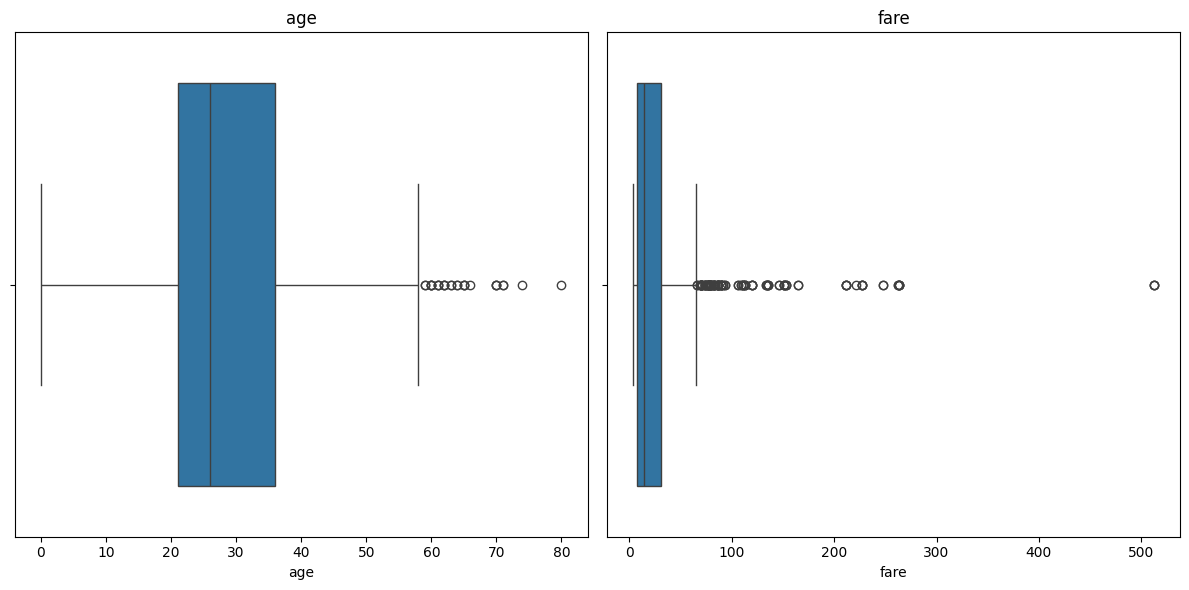

In [39]:
bootcampviztools.plot_multiple_boxplots(df_limpio,numericas)

Los valores de `fare` están muy dispersos, uno de ellos de manera muy extrema lo que distorsiona la media y mediana. Aunque `age` tiene valores dispersos, no son tantos y se puede ajustar el whishker

#### Distribución en valores

<Axes: >

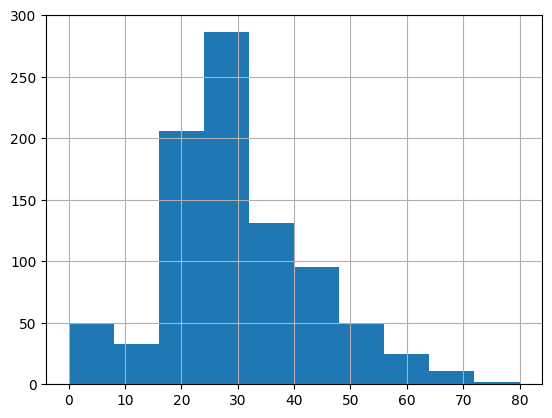

In [40]:
df_limpio["age"].hist()

<Axes: >

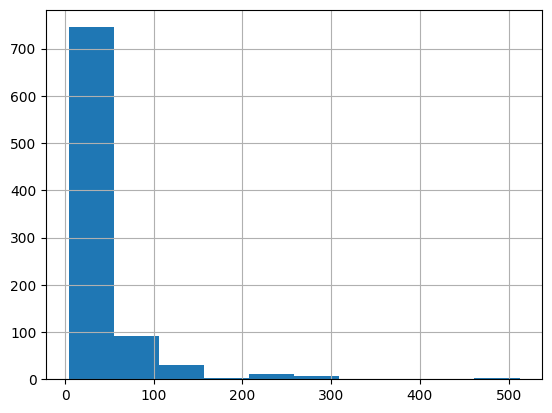

In [41]:
df_limpio["fare"].hist()

Los valores de `age` están bien distribuidos, con forma de campana de Gauss, quizá agrupados un poco a la izquierda, coincidiendo con lo observado en el perfil tipo: hombres jóvenes que viajan solos. \
Los valores de `fare` están muy concentrados en por debajo de los 50 ¿dólares?, pero se aprecia una cola larga.

#### Outliers

(2, 2)


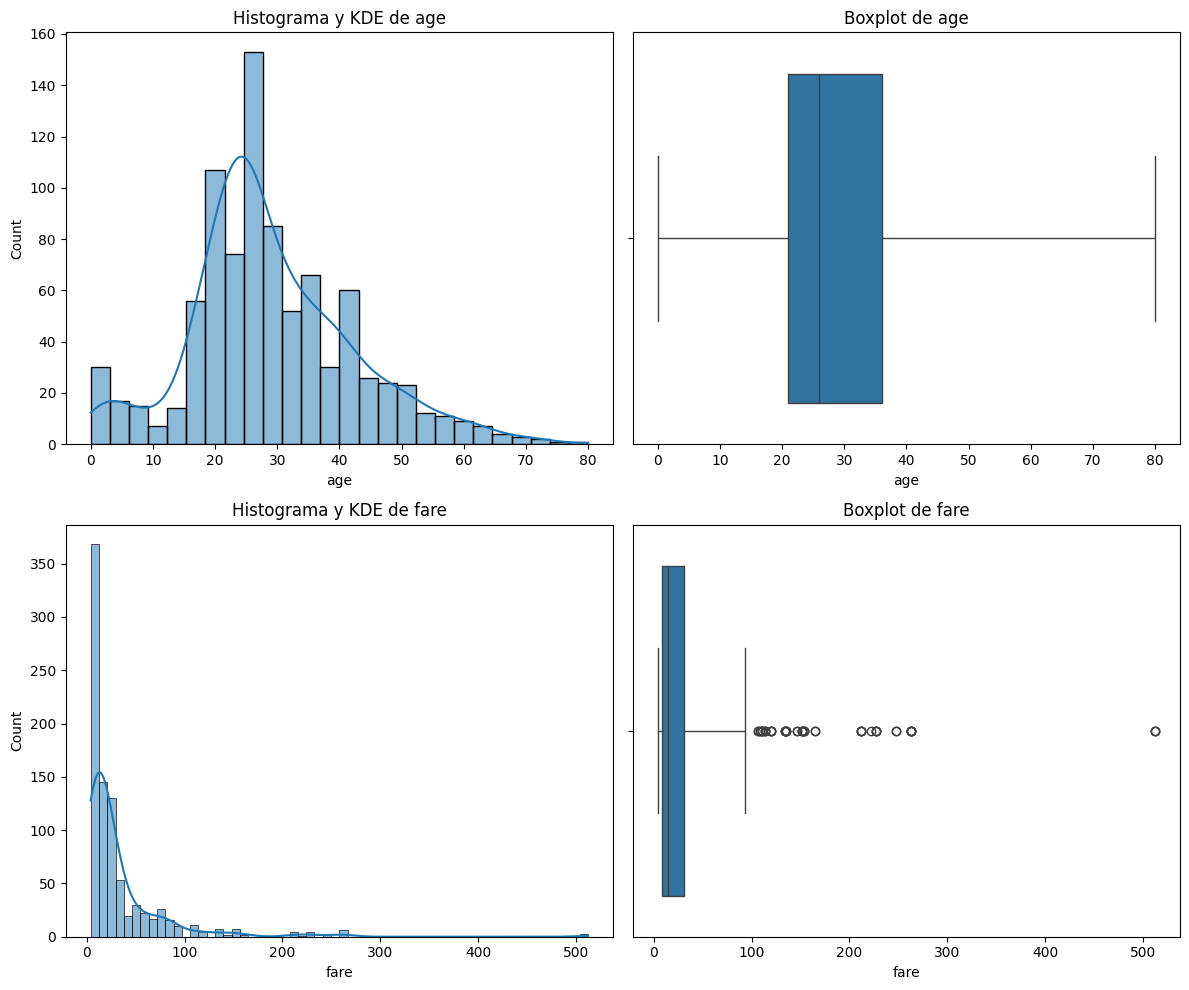

In [42]:
bootcampviztools.plot_combined_graphs(df_limpio, columns = numericas, whisker_width=3)

#### Preguntas para el análisis multivariante:
- Sería interesante ver los datos de supervivencia agrupados por clase. Se observa mucha mas mortalidad en hombres.
- En Southampton embarcó mucha gente, ¿está relacionado con la cantidad de gente de tercera clase y de hombres?
- El número de fallecidos es muy similar al número de hombres. ¿De qué tipo son los supervivientes?
- Se podría dividir `fare` en 3 bins: bajo, medio y alto.
- La mayoría de las personas tienen entre 22 y 38 años, pero existe una gran variabilidad en los extremos, sobre todo hacia la derecha.